In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost catboost lightgbm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
print(sys.executable)

/Users/yuls/Downloads/hw1/.venv/bin/python


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [6]:
print(df.shape)

(7043, 21)


In [7]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No        

In [8]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [9]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [10]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


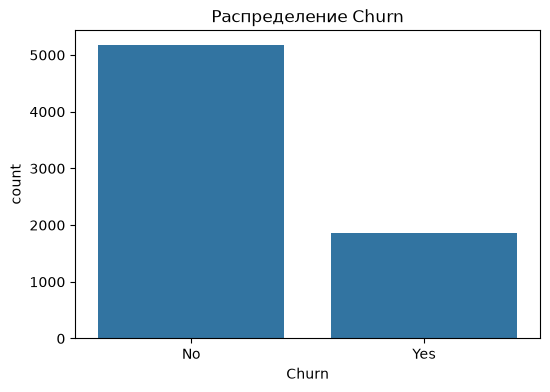

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='Churn')

plt.title('Распределение Churn')
plt.show()

print(df['Churn'].value_counts(normalize=True))

In [12]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

In [14]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [15]:
print(df['TotalCharges'].isna().sum())

11


In [16]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

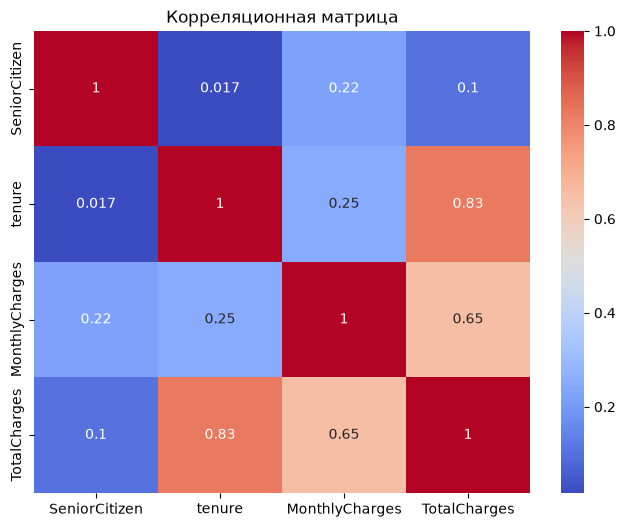

In [17]:
num_cols = [
    'SeniorCitizen',
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Корреляционная матрица')
plt.show()

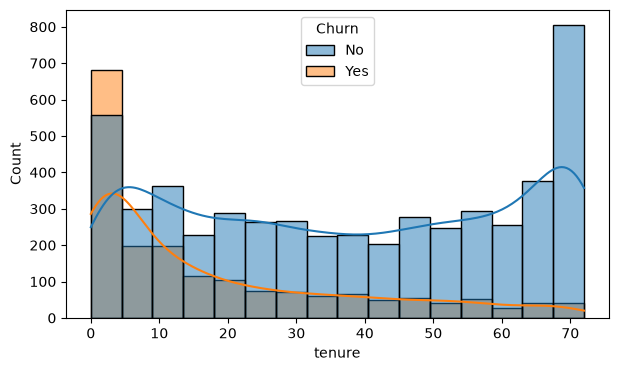

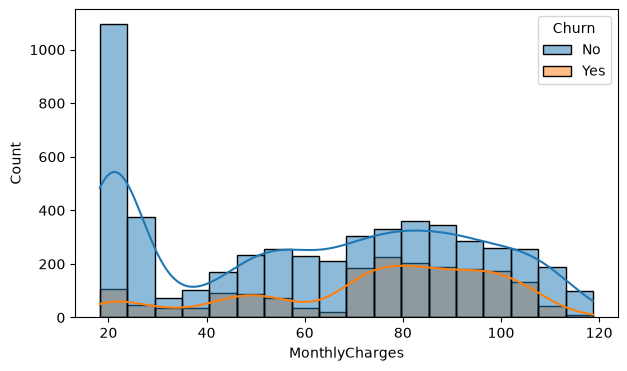

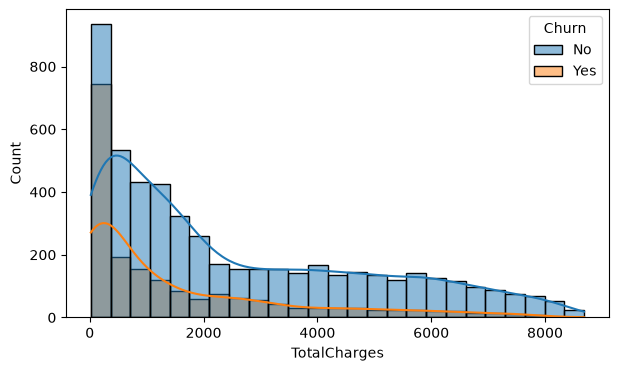

In [18]:
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:

    plt.figure(figsize=(7,4))

    sns.histplot(
        data=df,
        x=col,
        hue='Churn',
        kde=True
    )

    plt.show()

/var/folders/8y/k2vcs9v16yz9c1xrjh0t88b00000gn/T/ipykernel_17884/210153768.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


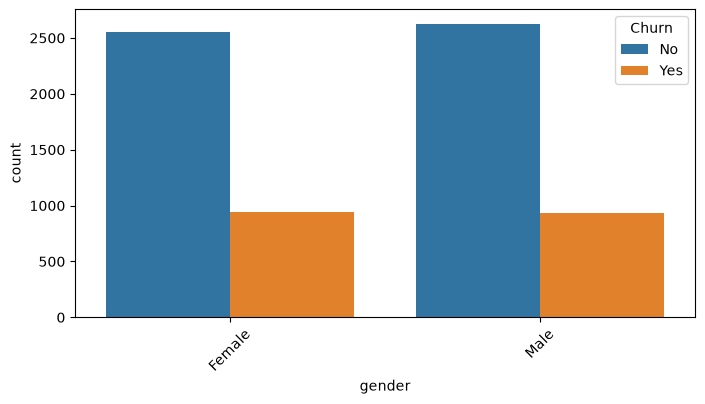

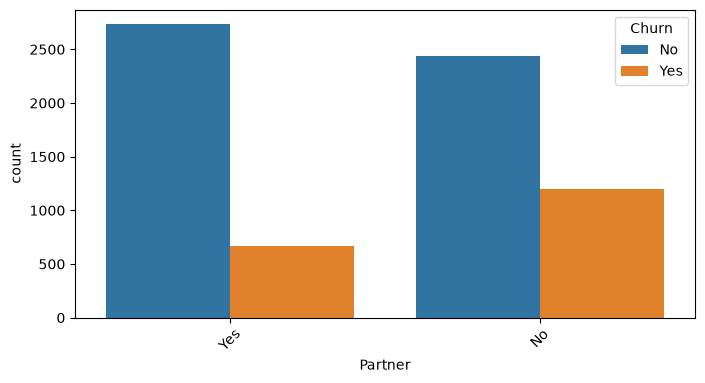

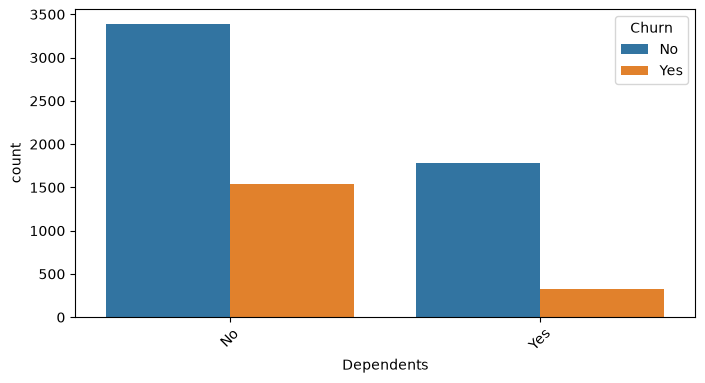

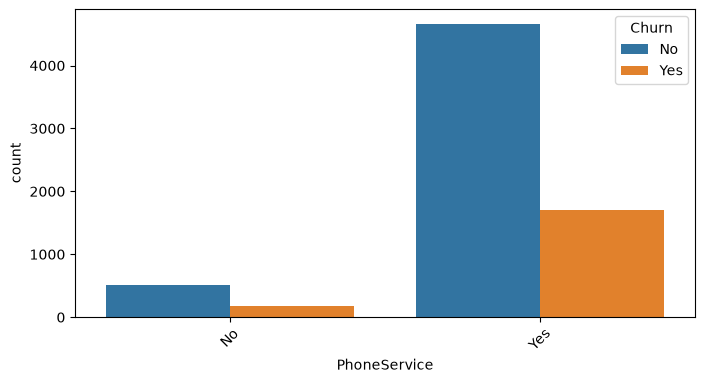

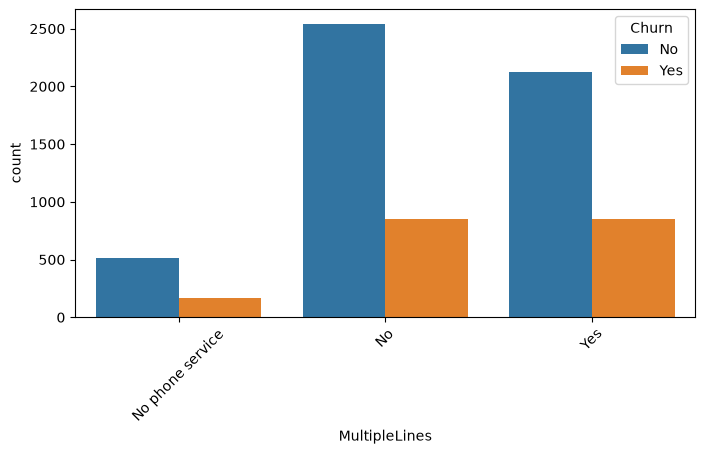

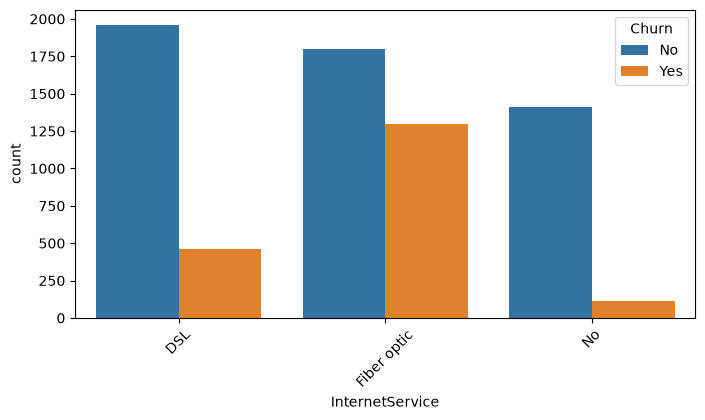

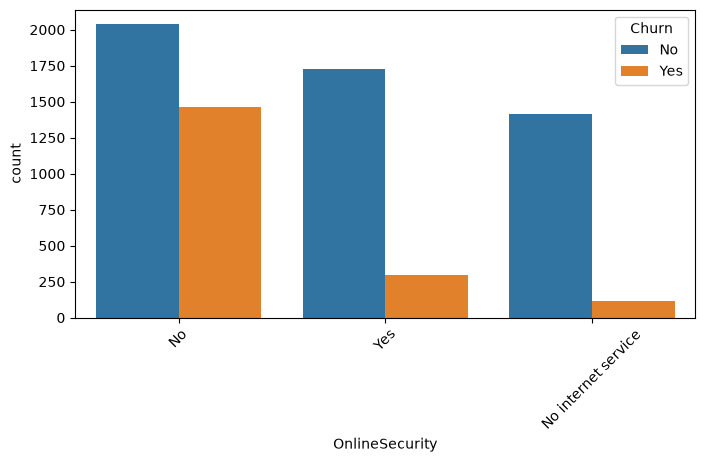

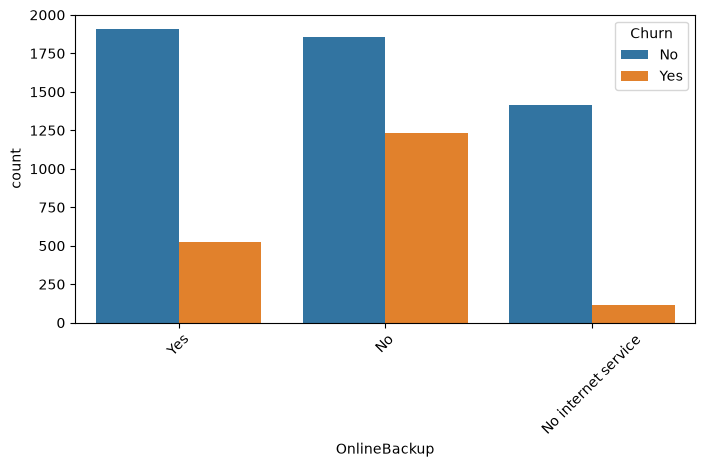

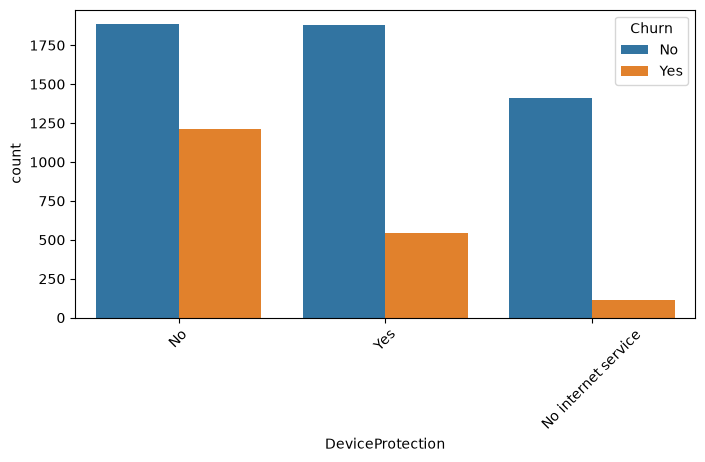

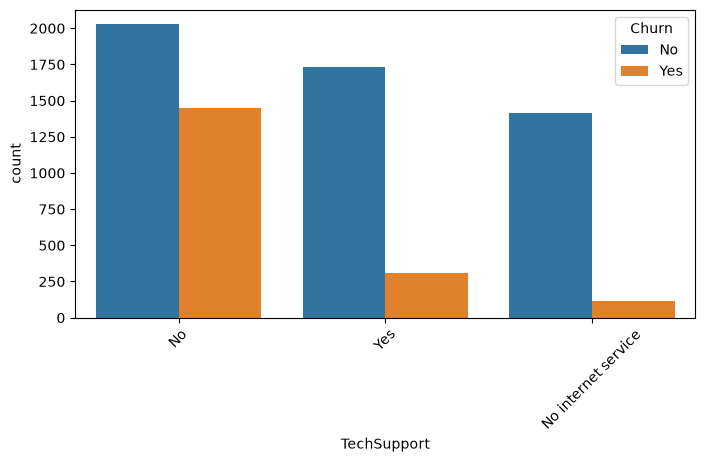

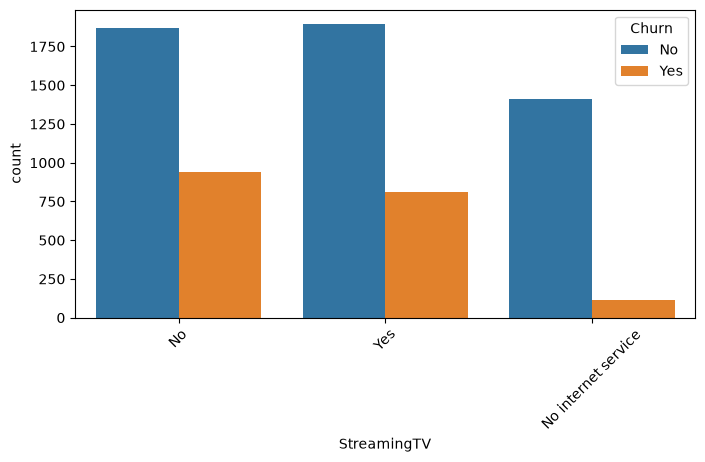

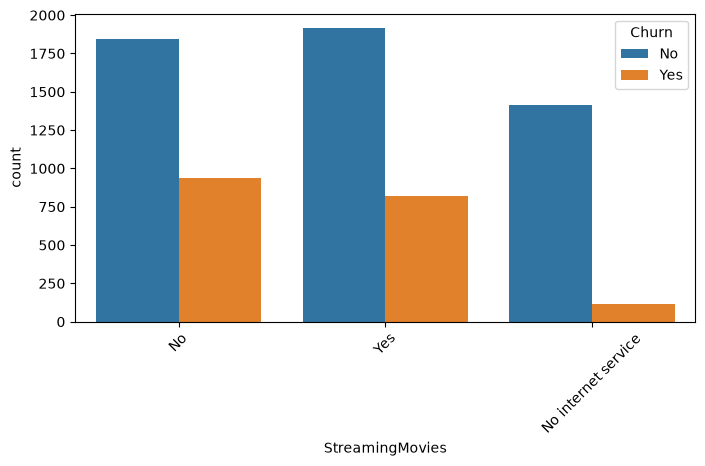

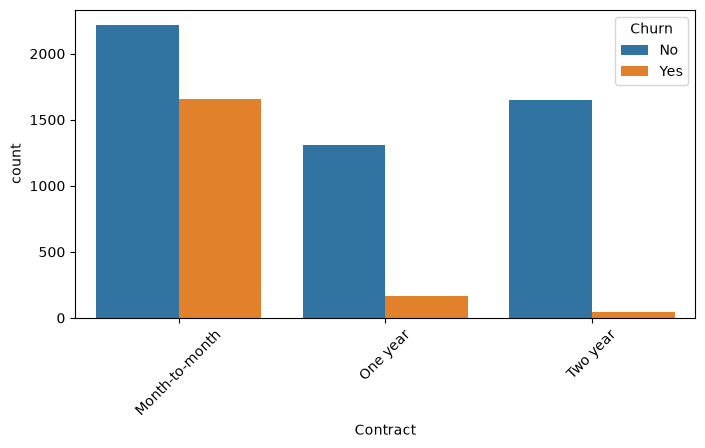

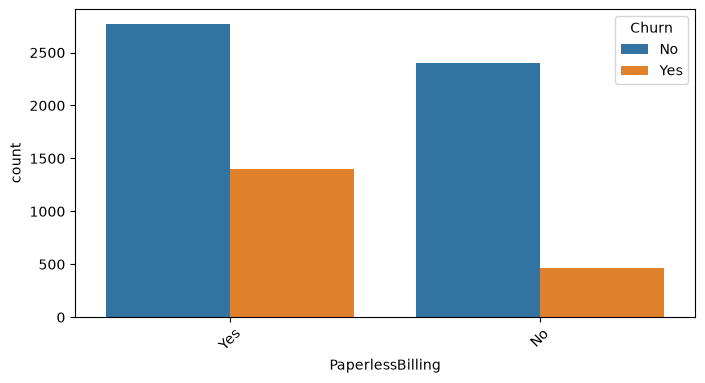

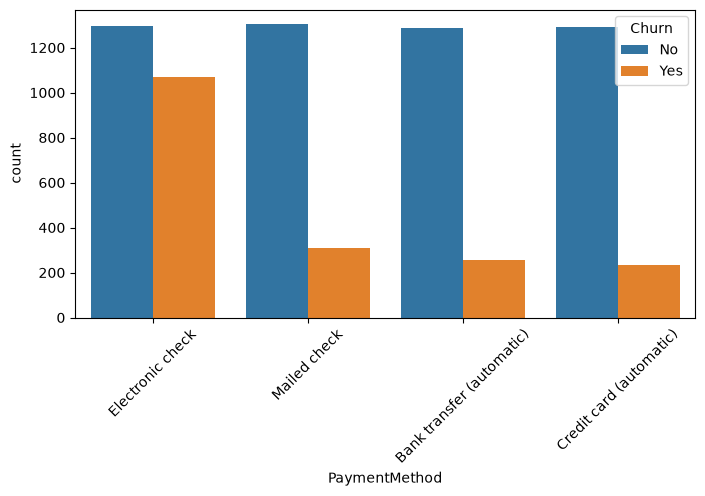

In [19]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:

    if col in ['customerID', 'Churn']:
        continue

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=col,
        hue='Churn'
    )

    plt.xticks(rotation=45)
    plt.show()

In [20]:
df = df.drop('customerID', axis=1)

In [21]:
df['AvgChargesPerMonth'] = (
    df['TotalCharges'] /
    (df['tenure'] + 1)
)

In [22]:
df['NewCustomer'] = np.where(
    df['tenure'] < 12,
    1,
    0
)

In [23]:
cat_cols = df.select_dtypes(include='object').columns

encoders = {}

for col in cat_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col])

    encoders[col] = le

/var/folders/8y/k2vcs9v16yz9c1xrjh0t88b00000gn/T/ipykernel_17884/683121702.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


In [24]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)

(5634, 21)
(1409, 21)


In [26]:
def evaluate_model(model, X_test, y_test):

    pred = model.predict(X_test)

    prob = model.predict_proba(X_test)[:,1]

    return {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC_AUC': roc_auc_score(y_test, prob)
    }

In [27]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

gb_results = evaluate_model(
    gb,
    X_test,
    y_test
)

gb_results

{'Accuracy': 0.801277501774308,
 'Precision': 0.6620689655172414,
 'Recall': 0.5133689839572193,
 'F1': 0.5783132530120482,
 'ROC_AUC': 0.8431450050375882}

In [28]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')

xgb.fit(X_train, y_train)

xgb_results = evaluate_model(
    xgb,
    X_test,
    y_test
)

xgb_results

{'Accuracy': 0.7906316536550745,
 'Precision': 0.6215384615384615,
 'Recall': 0.5401069518716578,
 'F1': 0.5779685264663805,
 'ROC_AUC': 0.8253313182980702}

In [29]:
cat = CatBoostClassifier(verbose=0, random_state=42)

cat.fit(X_train, y_train)

cat_results = evaluate_model(
    cat,
    X_test,
    y_test
)

cat_results

{'Accuracy': 0.7913413768630234,
 'Precision': 0.6360544217687075,
 'Recall': 0.5,
 'F1': 0.5598802395209581,
 'ROC_AUC': 0.8385995504921335}

In [30]:
lgbm = LGBMClassifier(random_state=42)

lgbm.fit(X_train, y_train)

lgbm_results = evaluate_model(
    lgbm,
    X_test,
    y_test
)

lgbm_results

[LightGBM] [Info] Number of positive: 1495, number of negative: 4139
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000956 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 883
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265353 -> initscore=-1.018328
[LightGBM] [Info] Start training from score -1.018328


{'Accuracy': 0.7885024840312278,
 'Precision': 0.6258278145695364,
 'Recall': 0.5053475935828877,
 'F1': 0.5591715976331361,
 'ROC_AUC': 0.8332752073161281}

In [31]:
results = pd.DataFrame({
    'GradientBoosting': gb_results,
    'XGBoost': xgb_results,
    'CatBoost': cat_results,
    'LightGBM': lgbm_results
}).T

results

,Accuracy,Precision,Recall,F1,ROC_AUC
GradientBoosting,0.801278,0.662069,0.513369,0.578313,0.843145
XGBoost,0.790632,0.621538,0.540107,0.577969,0.825331
CatBoost,0.791341,0.636054,0.500000,0.559880,0.838600
LightGBM,0.788502,0.625828,0.505348,0.559172,0.833275


In [32]:
gb_params = {
    'n_estimators':[100,200,300],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.8,1.0],
    'max_depth':[3,5]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

gb_grid.fit(X_train,y_train)

print(gb_grid.best_params_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [33]:
xgb_params = {
    'n_estimators':[100,200,300],
    'learning_rate':[0.01,0.05,0.1],
    'max_depth':[3,5,7],
    'subsample':[0.8,1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    xgb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

xgb_grid.fit(X_train,y_train)

print(xgb_grid.best_params_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [34]:
cat_params = {
    'iterations':[100,200,300],
    'learning_rate':[0.01,0.05,0.1],
    'depth':[4,6,8]
}

cat_grid = GridSearchCV(
    CatBoostClassifier(
        verbose=0,
        random_state=42
    ),
    cat_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

cat_grid.fit(X_train,y_train)

print(cat_grid.best_params_)

{'depth': 4, 'iterations': 100, 'learning_rate': 0.1}


In [35]:
lgbm_params = {
    'n_estimators':[100,200,300],
    'learning_rate':[0.01,0.05,0.1],
    'max_depth':[3,5,7],
    'subsample':[0.8,1.0]
}

lgbm_grid = GridSearchCV(
    LGBMClassifier(
        random_state=42
    ),
    lgbm_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

lgbm_grid.fit(X_train,y_train)

print(lgbm_grid.best_params_)

[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008403 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 883
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 21
[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265365 -> initscore=-1.018268
[LightGBM] [Info] Start training from score -1.018268
[LightGBM] [Info] Number of positive: 1196, number of negative: 3311
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004825 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [I

In [36]:
best_gb = gb_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_
best_cat = cat_grid.best_estimator_
best_lgbm = lgbm_grid.best_estimator_

In [37]:
final_results = pd.DataFrame({

    'GradientBoosting':
        evaluate_model(
            best_gb,
            X_test,
            y_test
        ),

    'XGBoost':
        evaluate_model(
            best_xgb,
            X_test,
            y_test
        ),

    'CatBoost':
        evaluate_model(
            best_cat,
            X_test,
            y_test
        ),

    'LightGBM':
        evaluate_model(
            best_lgbm,
            X_test,
            y_test
        )

}).T

final_results.sort_values(
    'ROC_AUC',
    ascending=False
)

,Accuracy,Precision,Recall,F1,ROC_AUC
XGBoost,0.805536,0.679856,0.505348,0.579755,0.847783
GradientBoosting,0.806246,0.686347,0.497326,0.576744,0.845815
LightGBM,0.799858,0.666667,0.491979,0.566154,0.845265
CatBoost,0.800568,0.657627,0.518717,0.579970,0.843615


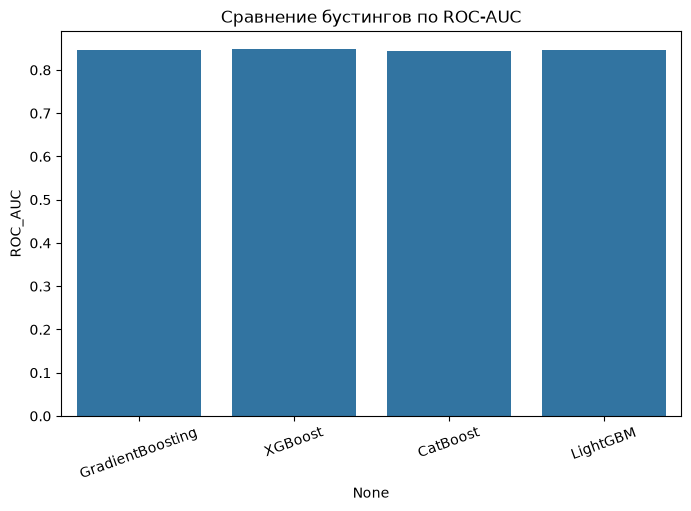

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=final_results.index,
    y=final_results['ROC_AUC']
)

plt.title('Сравнение бустингов по ROC-AUC')

plt.xticks(rotation=20)

plt.show()